In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import hamiltonians as hamiltonians
from pauli_matrices import *
import quantum_tools as qt
from floquet_tools import ccd_floquet

In [2]:
root_x = (1 / np.sqrt(2)) * np.array([[1, -1j], [-1j, 1]])

# Cheats Method

Firstly using cheats method of getting a $ \sqrt{X}$
- set $\epsilon_m$ to $\frac{\Omega}{16}  $ not just a quater
- this drags out the lengthof a root x to the optimal measurement time

### Second frame


In [3]:
def ccd_second_frame(epsilon_m, rabi_freq, theta_m, phi_0, t):
    """
    Second-order rotating-frame Hamiltonian H_rot^(2)(t).
    All frequencies should be in Hz.
    """
    epsilon_m = 2*np.pi*epsilon_m
    rabi_omega = 2*np.pi*rabi_freq

    cos_theta_m = np.cos(theta_m)
    sin_theta_m = np.sin(theta_m)
    cos_phi_mw = np.cos(phi_0)
    sin_phi_mw = np.sin(phi_0)

    cos_2omega_t = np.cos(2 * rabi_omega * t - theta_m)
    sin_2omega_t = np.sin(2 * rabi_omega * t - theta_m)

    H_static = (epsilon_m / 2) * (cos_theta_m * sigma_z + sin_theta_m * (-sin_phi_mw * sigma_x + cos_phi_mw * sigma_y))
    H_dynamic = (epsilon_m / 2) * (cos_2omega_t * sigma_z + sin_2omega_t * (-sin_phi_mw * sigma_x + cos_phi_mw * sigma_y))

    return H_static + H_dynamic

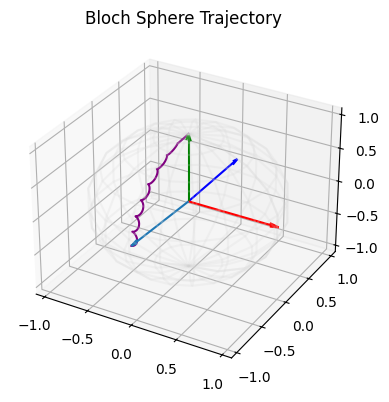

In [4]:
# Create a quantum system with a single qubit
natural_freq = 10 # this is 10Ghz
driving_freq = 10
rabi_freq = 0.005 # this is 5Mhz

detuning = -rabi_freq/1024
driving_freq = natural_freq + detuning

# note that we are setting phase_freq to rabi_freq/16
# we are also setting theta_m to pi2
# as well as phi_0 
phi_0, epsilon_m, phase_freq, theta_m = -np.pi/2, rabi_freq/16, rabi_freq, np.pi/2

# Integration parameters
tol = 10**-12
evaluation_points = 4000
evaluation_time = 4/rabi_freq # 4*the rabi period in ns

times, Us_second_frame = qt.calculate_unitaries(1, evaluation_time, evaluation_points, 
                                               ccd_second_frame,
                                               rabi_freq=rabi_freq,
                                               phi_0=phi_0,
                                               epsilon_m=epsilon_m,
                                               theta_m=theta_m,
                                               atol=tol,
                                               rtol=tol)

initial_state = np.array([1+0j, 0+0j])

states = []
for U in Us_second_frame:
    state = U @ initial_state
    states.append(state)

states = np.array(states)
qt.visualise_solution(times, states)

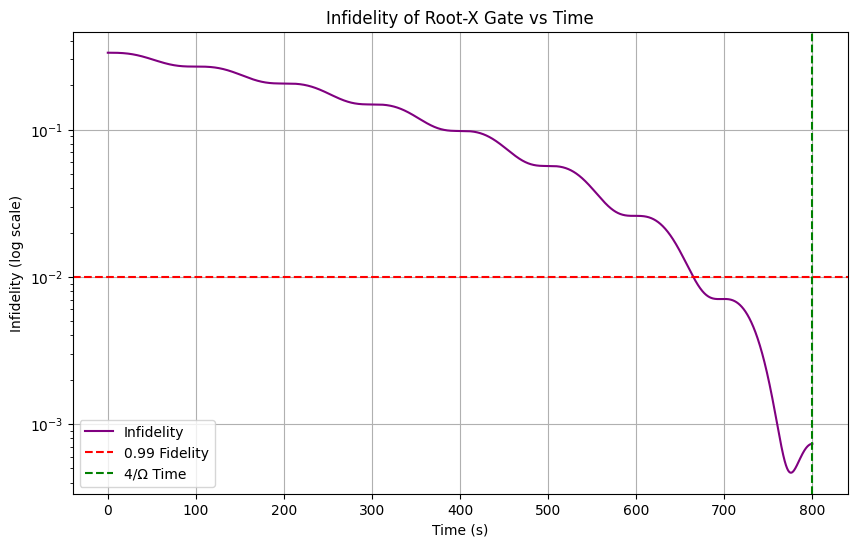

In [5]:

# Calculate fidelity with respect to root-X gate
fidelities = qt.calculate_fidelities(root_x, Us_second_frame, 2)
# Plot fidelity against time
plt.figure(figsize=(10, 6))
plt.semilogy(times, 1-fidelities, label='Infidelity', color='purple')
plt.axhline(y=0.01, color='r', linestyle='--', label='0.99 Fidelity')
plt.axvline(x=4/rabi_freq, color='g', linestyle='--', label='4/Ω Time')
plt.xlabel('Time (s)')
plt.ylabel('Infidelity (log scale)')
plt.title('Infidelity of Root-X Gate vs Time')
plt.legend()
plt.grid()
plt.show()



## First frame

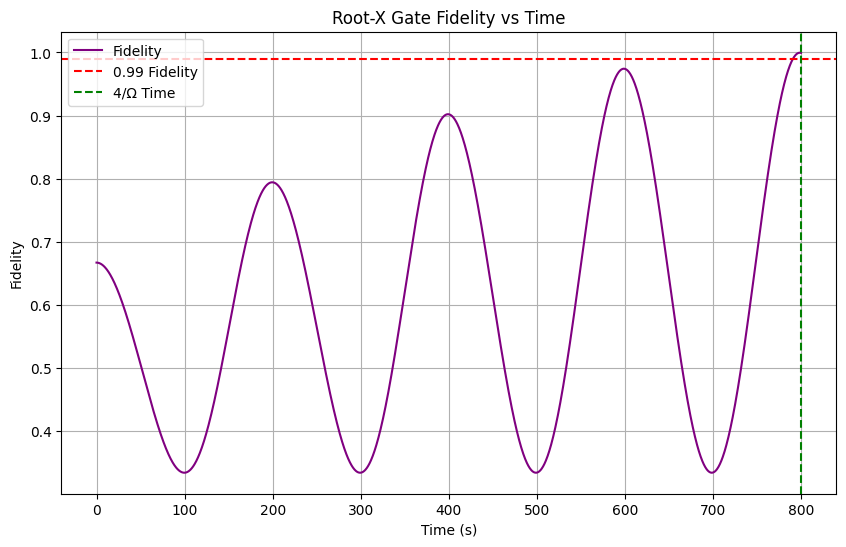

In [6]:
# Create a quantum system with a single qubit
natural_freq = 10 # this is 10Ghz
driving_freq = 10
rabi_freq = 0.005 # this is 5Mhz

# note that we are setting phase_freq to rabi_freq/16
# we are also setting theta_m to pi2
# as well as phi_0 
phi_0, epsilon_m, phase_freq, theta_m = np.pi/2, rabi_freq/16, rabi_freq, -np.pi/2

# Integration parameters
tol = 10**-7
evaluation_points = 2000
evaluation_time = 4/rabi_freq





fids_1 = []
fids_2 = []
fids_combined = []


# should be on resonance
times, Us_driving_frame = qt.calculate_unitaries(1, evaluation_time, evaluation_points,hamiltonians.ccd_rwa,
                        driving_freq=driving_freq,
                        natural_freq=natural_freq, rabi_freq=rabi_freq, phi_0=phi_0,
                        epsilon_m=epsilon_m,
                        phase_freq=phase_freq,
                        theta_m=theta_m)

fid = qt.calculate_fidelities(root_x, Us_driving_frame, 2)
# Plot fidelity against time
plt.figure(figsize=(10, 6))
plt.plot(times, fid, label='Fidelity', color='purple')
plt.axhline(y=0.99, color='r', linestyle='--', label='0.99 Fidelity')
plt.axvline(x=4/rabi_freq, color='g', linestyle='--', label='4/Ω Time')
plt.xlabel('Time (s)')
plt.ylabel('Fidelity')
plt.title('Root-X Gate Fidelity vs Time')
plt.grid(True)
plt.legend()
plt.show()


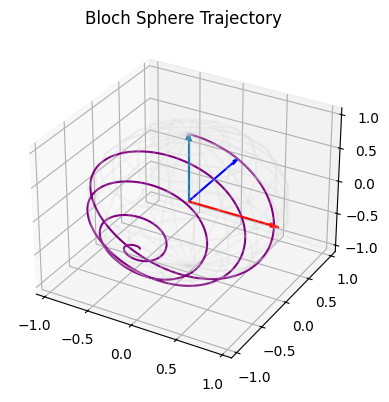

In [7]:
initial_state = np.array([1+0j, 0+0j])
states = []
for U in Us_driving_frame:
    state = U @ initial_state
    states.append(state)

    
qt.visualise_solution(times, np.array(states[::-1]))

# Try optimising the parameters to get root x at optimal measurment times
- optimise theta, phi and epsilon m to give use best measurement at 4*rabi_period

In [ ]:
import numpy as np
from scipy.optimize import minimize



# Create a quantum system with a single qubit
natural_freq = 10 # this is 10Ghz
driving_freq = 10
rabi_freq = 0.005 # this is 5Mhz

# note that we are setting phase_freq to rabi_freq/16
# we are also setting theta_m to pi2
# as well as phi_0 
phi_0, epsilon_m, phase_freq, theta_m = np.pi/2, rabi_freq/4, rabi_freq, np.pi/2


evaluation_points = 100000
evaluation_time = 4/rabi_freq # = 
tol = 10**-12

# Define target root-X gate
root_x = (1 / np.sqrt(2)) * np.array([[1, -1j], [-1j, 1]])

# Objective function: 1 - fidelity (since we are minimising)
def objective(params):
    epsilon_m, phi, theta, detuning = params

    try:
        _, Us_driving_frame = qt.calculate_unitaries(1, evaluation_time, evaluation_points,hamiltonians.ccd_rwa,
                        driving_freq=driving_freq+detuning*rabi_freq,
                        natural_freq=natural_freq, rabi_freq=rabi_freq, phi_0=phi*np.pi,
                        epsilon_m=epsilon_m*rabi_freq,
                        phase_freq=phase_freq,
                        theta_m=theta*np.pi,
                        rtol=tol, atol = tol)
       
        fid = qt.calculate_fidelities(root_x, Us_driving_frame, 2)
        return 1 - fid[-1]  # We want to maximise fidelity, so minimise 1 - fidelity

    except Exception as e:
        print(f"Error during evaluation: {e}")
        return 1  # Return high loss if something breaks

# Initial guess and bounds
initial_guess = [1/4, 1/2, -1/2, 0]
bounds = [(1/4, 1/4), (-2, 2), (-2, 2), (-0.000, 0.000)]

# Run optimisation
result = minimize(objective, initial_guess, bounds=bounds, method='L-BFGS-B')

# Extract and print optimal values
optimal_epsilon_m, optimal_phi, optimal_theta, optimal_detuning= result.x
optimal_fidelity = 1 - result.fun

print(f"✅ Optimal εₘ: {optimal_epsilon_m} x Ω ")
print(f"✅ Optimal φ: {optimal_phi} x π ")
print(f"✅ Optimal θ: {optimal_theta} x π ")
print(f"✅ Optimal detuning: {optimal_detuning} x Ω ")
print(f"🎯 Max Fidelity: {optimal_fidelity}")

✅ Optimal εₘ: 0.25 x Ω 
✅ Optimal φ: 1.4398443055807721 x π 
✅ Optimal θ: -0.49999792096036894 x π 
✅ Optimal detuning: -0.0 x Ω 
🎯 Max Fidelity: 0.6708097454668502


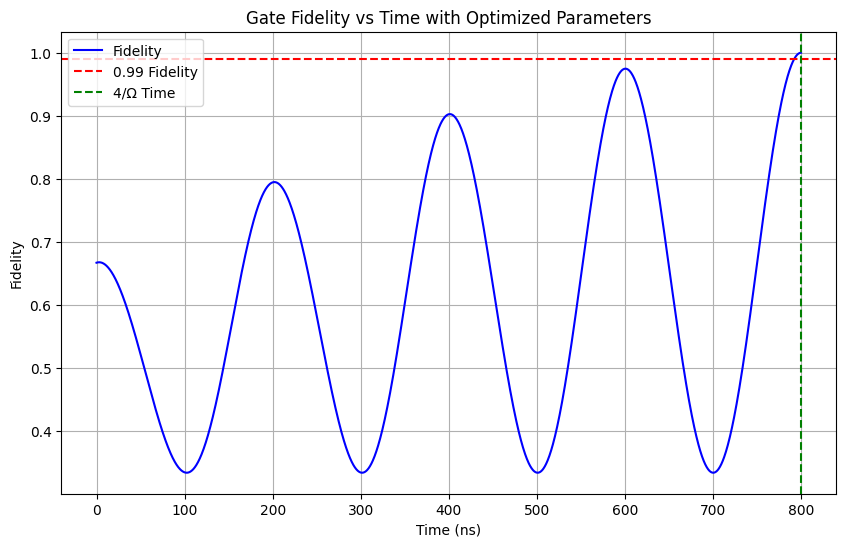

In [9]:
# Use optimized parameters
natural_freq = 10  # 10GHz
driving_freq = 10
rabi_freq = 0.005  # 5MHz

# Use the optimized parameters from the optimization
epsilon_m = optimal_epsilon_m * rabi_freq
phi_0 = optimal_phi*np.pi
theta_m = optimal_theta*np.pi

detuning = optimal_detuning * rabi_freq
driving_freq = natural_freq + detuning

# epsilon_m = rabi_freq/16
# phi_0 = np.pi/2
# theta_m = np.pi/2
# phase_freq = rabi_freq


# Integration parameters - run for 16 rabi periods
evaluation_points = 2000
evaluation_time = 4/rabi_freq  # 16 times the rabi period

# Calculate unitaries and fidelities
times, Us_driving_frame = qt.calculate_unitaries(1, evaluation_time, evaluation_points, 
                                               hamiltonians.ccd_rwa,
                                               driving_freq=driving_freq,
                                               natural_freq=natural_freq, 
                                               rabi_freq=rabi_freq, 
                                               phi_0=phi_0,
                                               epsilon_m=epsilon_m,
                                               phase_freq=phase_freq,
                                               theta_m=theta_m)

# Calculate fidelity with root-X gate
fidelities = qt.calculate_fidelities(root_x, Us_driving_frame, 2)

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(times, fidelities, 'b-', label='Fidelity')
plt.axhline(y=0.99, color='r', linestyle='--', label='0.99 Fidelity')
plt.axvline(x=4/rabi_freq, color='g', linestyle='--', label='4/Ω Time')

plt.xlabel('Time (ns)')
plt.ylabel('Fidelity')
plt.title('Gate Fidelity vs Time with Optimized Parameters')
plt.grid(True)
plt.legend()
plt.show()

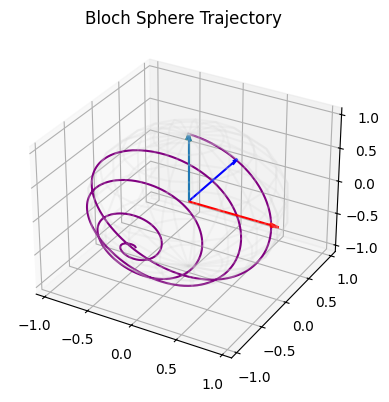

In [10]:
initial_state = np.array([1+0j, 0+0j])
states = []
for U in Us_driving_frame:
    state = U @ initial_state
    states.append(state)

    
qt.visualise_solution(times, np.array(states[::-1]))


# Second Qubit


- So we have found a reliable way to apply root X to the first qubit - but what does this scheme do to the second?
- What does it do in the previously found frame?
- Can we optimise either the frame or the root X to compensate for this?

In [11]:
import pickle
import sympy as sp
import os


# Load the saved symbolic data
with open('quasienergies_functions/ccd_quasienergy_6.pkl', 'rb') as f_in:
    loaded_data = pickle.load(f_in)

expr = loaded_data['expression'] 
symbol_list = loaded_data['symbols']


delta_symbol, Omega_symbol, phi_0_symbol, epsilon_symbol, omega_m_symbol, theta_m_symbol, lam_symbol = sp.symbols('delta Omega phi_0 epsilon omega_m theta_m lam')
# Create symbolic variables


# Calculate value using same parameters
#note try calculating in hz if that doesnt work try rads
value = 2*float(sp.re(expr.evalf(subs={
    delta_symbol: 0.2,
    Omega_symbol: rabi_freq,
    epsilon_symbol: epsilon_m,
    omega_m_symbol: phase_freq,
})))

# calulate the effective rabi freq for the same values
effective_rabi = np.sqrt(rabi_freq**2 + (0.2)**2)
print(f"Effective rabi frequency: {effective_rabi}")
print(f"Quasienergy value: {value}")


Effective rabi frequency: 0.2000624902374256
Quasienergy value: 0.20006249054191208


## Find the combined fidelity.


In [33]:

natural_freq = 10 # this is 10Ghz
driving_freq = 10
rabi_freq = 0.005 # this is 5Mhz

# note that we are setting phase_freq to rabi_freq/16
# we are also setting theta_m to pi2
# as well as phi_0 
phi_0, epsilon_m, phase_freq, theta_m = np.pi/2, rabi_freq/16, rabi_freq, -np.pi/2

# Integration parameters
tol = 10**-7
evaluation_points = 2000
evaluation_time = 4/rabi_freq

detunings = np.linspace(0, 0.1, 1000)

fids_1 = []
fids_2 = []
fids_combined = []

# First calculate fidelity for qubit 1 (root-x gate)
times, Us_driving_frame = qt.calculate_unitaries(1, evaluation_time, evaluation_points, hamiltonians.ccd_rwa,
                            driving_freq=driving_freq,
                            natural_freq=natural_freq, 
                            rabi_freq=rabi_freq, 
                            phi_0=phi_0,
                            epsilon_m=epsilon_m,
                            phase_freq=phase_freq,
                            theta_m=theta_m)
fid_1 = qt.calculate_fidelities(root_x, Us_driving_frame, 2)

# For each detuning, calculate fidelity for qubit 2 (identity gate)
for detuning in detunings:
    fids_1.append(fid_1)
    # calculate the effective the ccd time evolution unitaries
    times, Us_driving_frame = qt.calculate_unitaries(1, evaluation_time, evaluation_points, hamiltonians.ccd_rwa,
                            driving_freq=driving_freq,
                            natural_freq=natural_freq-detuning, 
                            rabi_freq=rabi_freq, 
                            phi_0=phi_0,
                            epsilon_m=epsilon_m,
                            phase_freq=phase_freq,
                            theta_m=theta_m)
    
    # rotate the unitaries to some frame
    # Convert sympy expression to numpy complex
    # floquet_freq = np.sign(detuning)*2*complex(expr.evalf(subs={
    #                 delta_symbol: detuning,
    #                 Omega_symbol: rabi_freq,
    #                 epsilon_symbol: epsilon_m,
    #                 omega_m_symbol: phase_freq,
    #                 }))
    ccd_floquet_freq = np.sign(detuning)*2*ccd_floquet(natural_freq-detuning, driving_freq, rabi_freq, phi_0, epsilon_m, phase_freq, theta_m)[4]

    transformed_Us = qt.phase_boost_unitaries(Us_driving_frame, ccd_floquet_freq, times)

    # Calculate fidelity for qubit 2 (identity gate)
    fid_2 = qt.calculate_fidelities(np.eye(2), transformed_Us, 2)
    fids_2.append(fid_2)
    
    # Calculate combined fidelity
    fid_combined = (np.abs((6*fid_1-2)*(6*fid_2-2))+4)/20
    fids_combined.append(fid_combined)





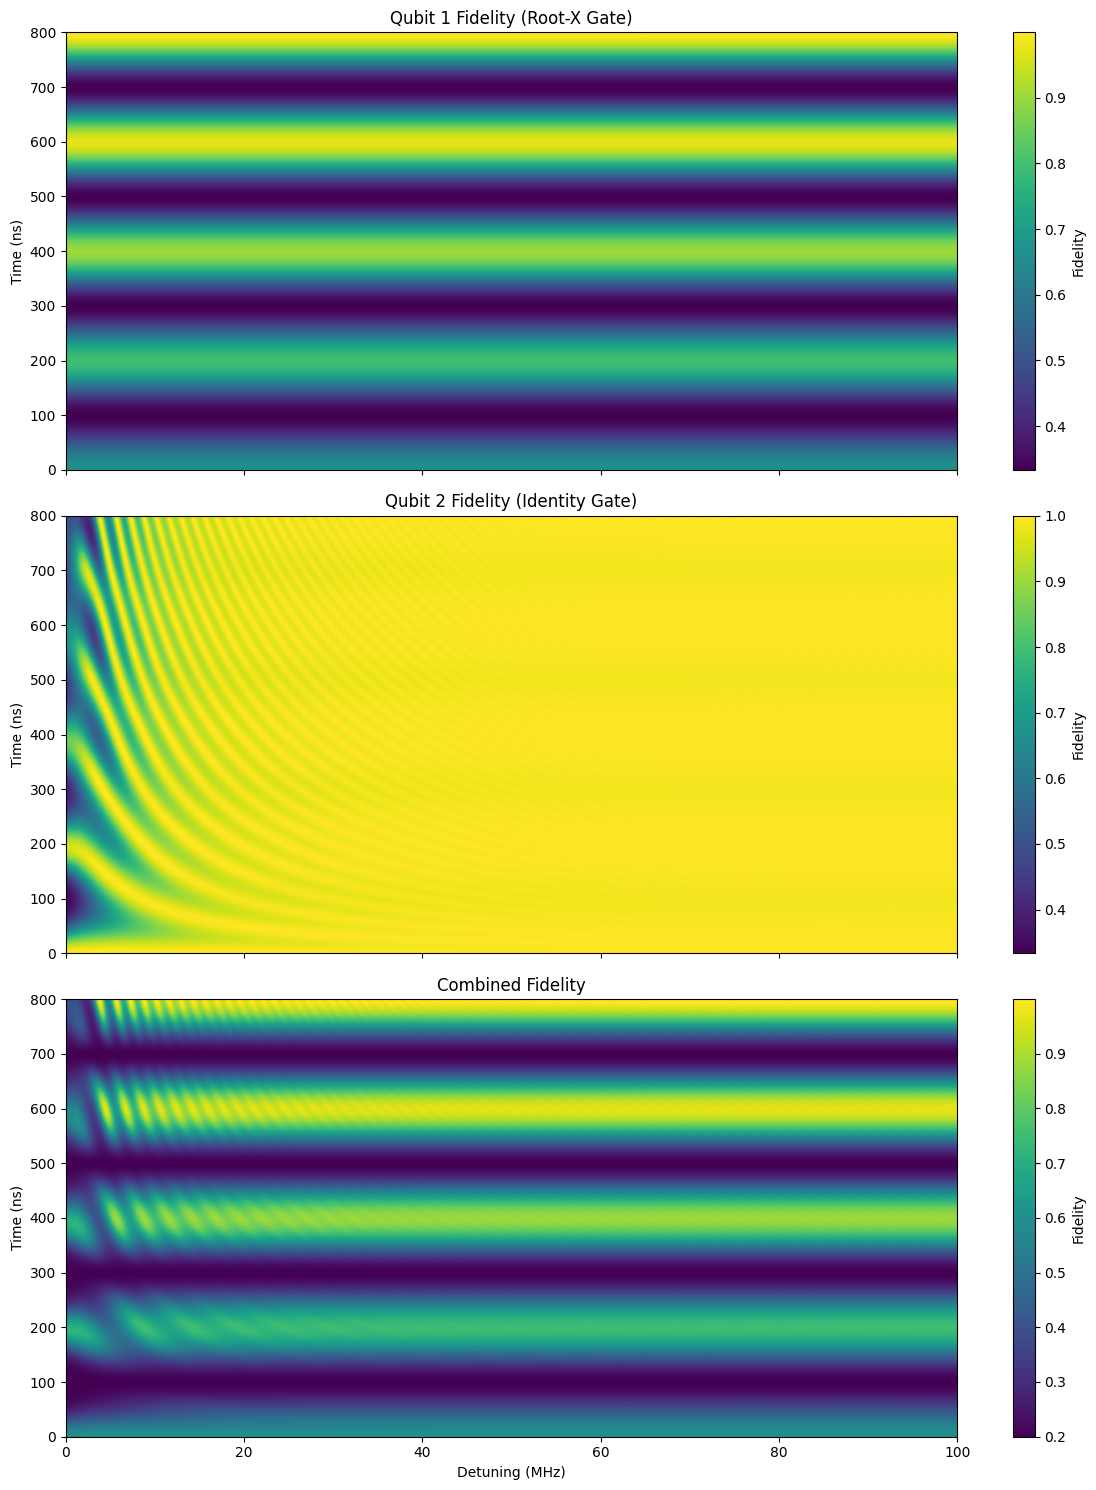

In [34]:
# Convert detunings to MHz for display
detunings_mhz = detunings * 10**3

# Create figure with 3 subplots
fig, axs = plt.subplots(3, 1, figsize=(12, 15), sharex=True)

# Plot fidelity for qubit 1 (root-x gate)
im1 = axs[0].imshow(np.array(fids_1).T, aspect='auto', 
                  extent=[detunings_mhz[0], detunings_mhz[-1], times[0], times[-1]], 
                  origin='lower', cmap='viridis')
axs[0].set_ylabel('Time (ns)')
axs[0].set_title('Qubit 1 Fidelity (Root-X Gate)')
axs[0].axhline(y=4/rabi_freq, color='r', linestyle='--', label='4/Ω Time')
fig.colorbar(im1, ax=axs[0], label='Fidelity')

# Plot fidelity for qubit 2 (identity gate)
im2 = axs[1].imshow(np.array(fids_2).T, aspect='auto', 
                  extent=[detunings_mhz[0], detunings_mhz[-1], times[0], times[-1]], 
                  origin='lower', cmap='viridis')
axs[1].set_ylabel('Time (ns)')
axs[1].set_title('Qubit 2 Fidelity (Identity Gate)')
axs[1].axhline(y=4/rabi_freq, color='r', linestyle='--', label='4/Ω Time')
fig.colorbar(im2, ax=axs[1], label='Fidelity')

# Plot combined fidelity
im3 = axs[2].imshow(np.array(fids_combined).T, aspect='auto', 
                  extent=[detunings_mhz[0], detunings_mhz[-1], times[0], times[-1]], 
                  origin='lower', cmap='viridis')
axs[2].set_xlabel('Detuning (MHz)')
axs[2].set_ylabel('Time (ns)')
axs[2].set_title('Combined Fidelity')
axs[2].axhline(y=4/rabi_freq, color='r', linestyle='--', label='4/Ω Time')
fig.colorbar(im3, ax=axs[2], label='Fidelity')

plt.tight_layout()
plt.show()

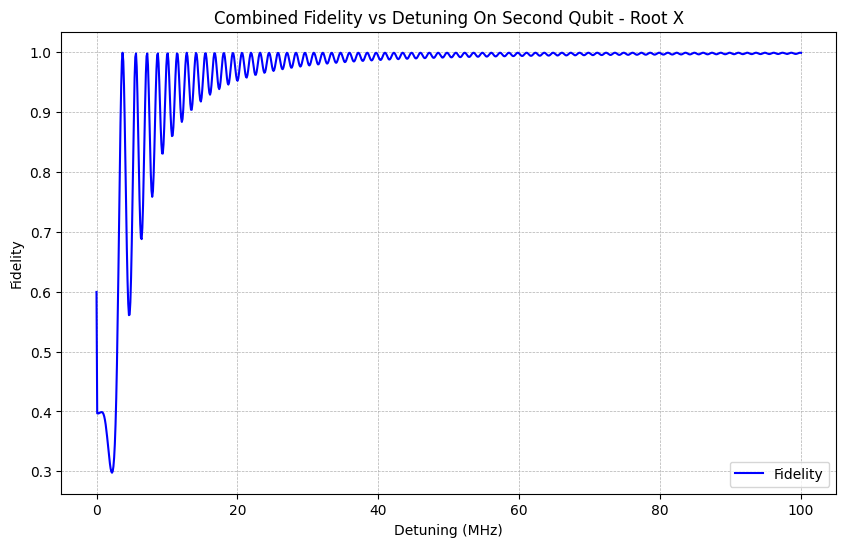

In [35]:
# Extract the combined fidelity at the final time step
final_fidelity = np.array(fids_combined)[:, -1]

# Convert detunings to MHz for display
detunings_mhz = detunings * 10**3

# Plot the combined fidelity against detuning
plt.figure(figsize=(10, 6))
plt.plot(detunings_mhz, final_fidelity, label='Fidelity', color='blue')
# plt.axhline(y=0.99, color='r', linestyle='--', label='0.99 Fidelity Threshold')
plt.xlabel('Detuning (MHz)')
plt.ylabel('Fidelity')
plt.title('Combined Fidelity vs Detuning On Second Qubit - Root X') 
plt.grid(True, linestyle='--', linewidth=0.5)
plt.legend()
plt.show()

In [21]:
np.save("ccd_root_x_combined_fids.npy", final_fidelity) 
np.save("ccd_root_x_detunings.npy", detunings_mhz)

So I dont think this looks that good - try sympying the root x floquet stuff
plot phase accumulation

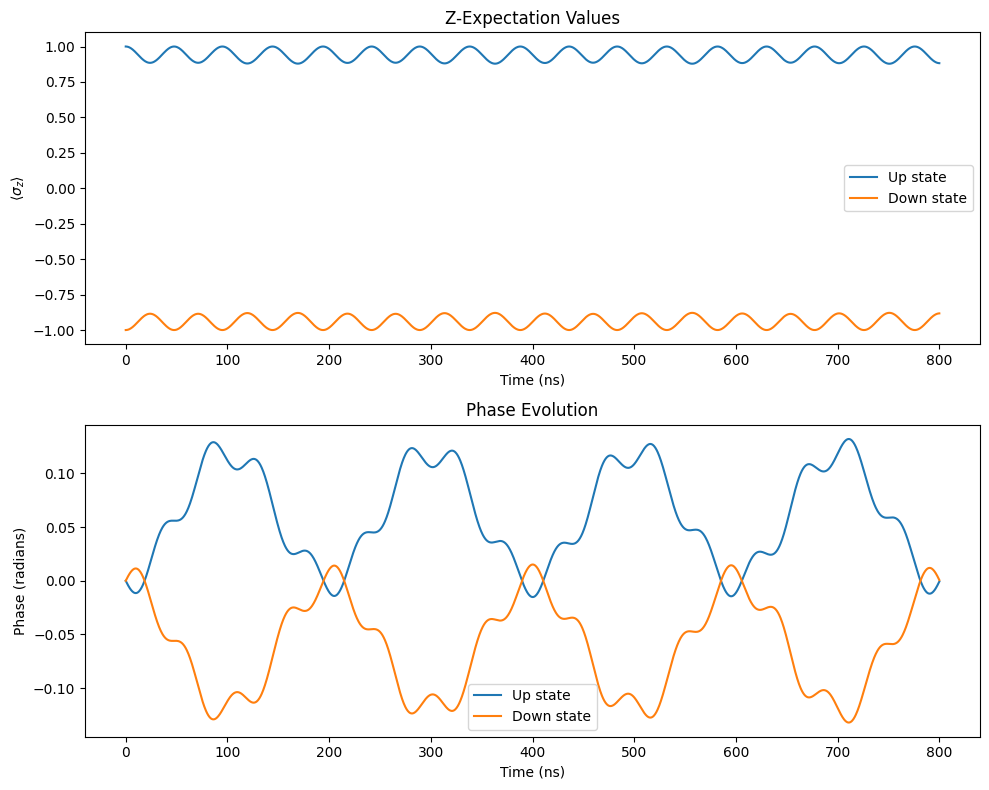

In [31]:
# Create initial states
up_state = np.array([1 + 0j, 0 + 0j])
down_state = np.array([0 + 0j, 1 + 0j])

# Calculate evolution for both states
up_states = np.array([U @ up_state for U in transformed_Us])
down_states = np.array([U @ down_state for U in transformed_Us])
# Calculate z expectations
up_z_exp = qt.calculate_expectations(up_states, sigma_z)
down_z_exp = qt.calculate_expectations(down_states, sigma_z)

# Calculate phases (using the first component of each state)
# Calculate phases - taking angle of the largest component for each state
up_phases = np.angle(up_states[:, np.argmax(np.abs(up_states[0]))])
down_phases = np.angle(down_states[:, np.argmax(np.abs(down_states[0]))])

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# Plot Z expectations
ax1.plot(times, up_z_exp, label='Up state')
ax1.plot(times, down_z_exp, label='Down state')
ax1.set_xlabel('Time (ns)')
ax1.set_ylabel(r'$\langle\sigma_z\rangle$')
ax1.set_title('Z-Expectation Values')
ax1.legend()

# Plot phases
ax2.plot(times, up_phases, label='Up state')
ax2.plot(times, down_phases, label='Down state')
ax2.set_xlabel('Time (ns)')
ax2.set_ylabel('Phase (radians)')
ax2.set_title('Phase Evolution')
ax2.legend()

plt.tight_layout()
plt.show()

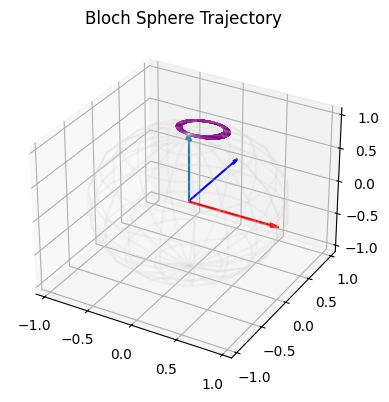

In [36]:
    
qt.visualise_solution(times, np.array(up_states[::-1]))

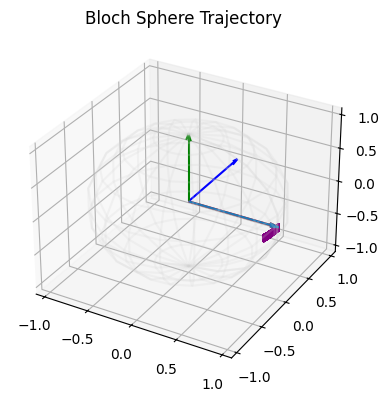

In [37]:
down_state = (1/np.sqrt(2))*np.array([1 + 0j, 1 + 0j])
down_states = np.array([U @ down_state for U in transformed_Us])
qt.visualise_solution(times, np.array(down_states[::-1]))